In [1]:
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

from utils.config import (
    XMAX, YMAX, T_MAX, NX, NY, NT, DT,
    T_BOUNDARY, T_INITIAL, T_SAFE, DELTA_T,
    MEAT_PROPERTIES, TEST_MEAT,
)
from utils.dataset    import (build_ann_dataloaders, sample_collocation_points,
                               load_meat_data, normalise_inputs)
from utils.models     import ANN, PINN
from utils.training   import train_ann, train_pinn
from utils.evaluation import (evaluate_model, plot_loss_curves,
                               plot_field_comparison, plot_centre_temperature,
                               print_metrics_table)
from utils.fourier    import T_fourier_grid, T_fourier_centre_history
import matplotlib.pyplot as plt

# ── Device selection ──────────────────────────────────────────────────────────
# Preference order: NVIDIA CUDA → Apple Silicon Metal (MPS) → CPU.
# The macOS PyTorch wheel ships the MPS backend, which runs this project on the
# integrated GPU of an M-series Mac. All tensors in utils/ are float32, which is
# what MPS supports, so no other change is required.

def get_device():
    """Return the fastest accelerator available on this machine."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    mps = getattr(torch.backends, 'mps', None)
    if mps is not None and mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def device_name(dev):
    """Human-readable name for the selected device."""
    if dev.type == 'cuda':
        return torch.cuda.get_device_name(dev)
    if dev.type == 'mps':
        return 'Apple Silicon GPU (Metal / MPS)'
    return 'CPU'


device = get_device()

GLOBAL_SEED = 42

def set_seed(seed=GLOBAL_SEED):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)          # seeds the CPU, CUDA and MPS generators
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

set_seed(GLOBAL_SEED)
print(f"Global seed : {GLOBAL_SEED} (call set_seed() to reset before each experiment)")
print(f"Device      : {device}")
print(f"Device name : {device_name(device)}")
print(f"PyTorch     : {torch.__version__}")


Global seed : 42 (call set_seed() to reset before each experiment)
Device      : mps
Device name : Apple Silicon GPU (Metal / MPS)
PyTorch     : 2.8.0


---
## Section 2: Reference Data

In [2]:
# ── Load FDM reference datasets ───────────────────────────────────────────────
DATA_DIR = "data"
fdm_data = {}

print("Loading FDM reference datasets...")
for meat in MEAT_PROPERTIES:
    raw   = load_meat_data(DATA_DIR, meat)
    props = MEAT_PROPERTIES[meat]
    nx_int, ny_int = NX - 2, NY - 2
    n_spatial = nx_int * ny_int

    x_grid = np.linspace(0, XMAX, NX)
    y_grid = np.linspace(0, YMAX, NY)
    t_grid = np.arange(NT) * DT

    u = np.full((NX, NY, NT), T_BOUNDARY)
    for it in range(NT):
        u[1:-1, 1:-1, it] = raw['T'][it*n_spatial:(it+1)*n_spatial].reshape(nx_int, ny_int)

    fdm_data[meat] = {'u': u, 'x': x_grid, 'y': y_grid, 't': t_grid,
                       'rho': props['rho'], 'cp': props['cp'], 'k': props['k']}
    alpha = props['k'] / (props['rho'] * props['cp'])
    print(f"  {meat:8s}: alpha={alpha:.3e} m²/s | T_centre(final)={u[NX//2,NY//2,-1]:.2f} K")


Loading FDM reference datasets...
  beef    : alpha=1.589e-07 m²/s | T_centre(final)=339.66 K
  chicken : alpha=1.189e-07 m²/s | T_centre(final)=320.58 K
  pork    : alpha=1.617e-07 m²/s | T_centre(final)=340.97 K


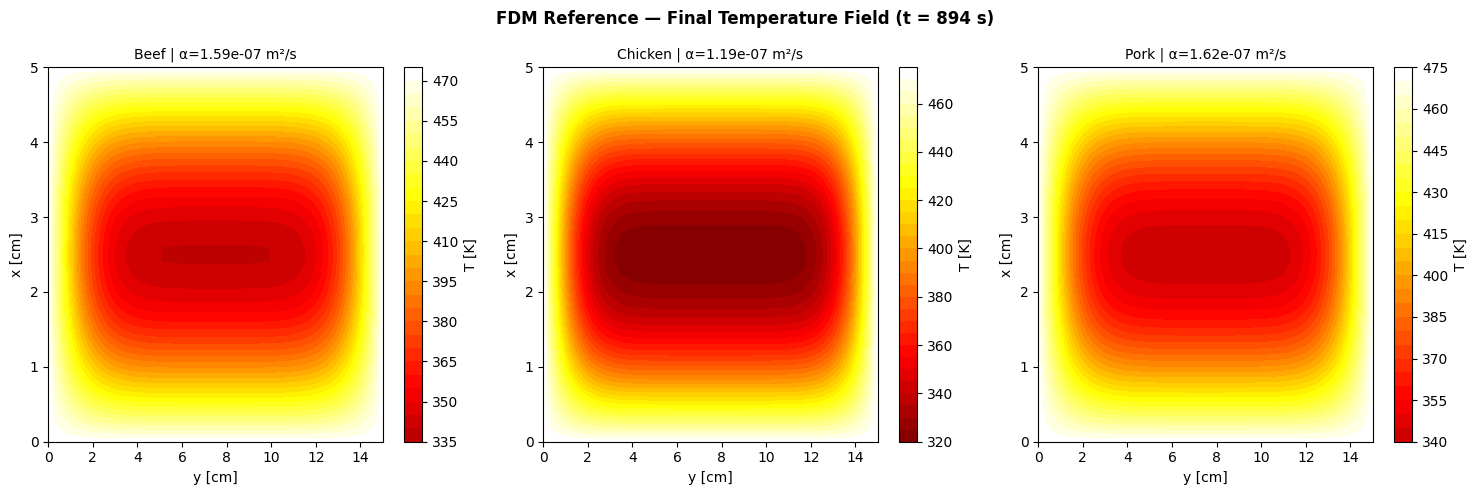

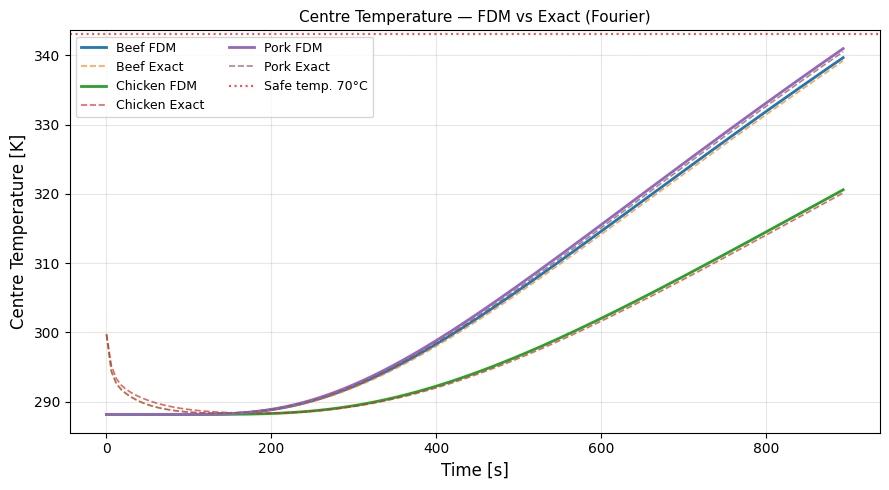

In [3]:
# ── Visualise reference fields ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (meat, sol) in zip(axes, fdm_data.items()):
    im = ax.contourf(sol['y']*100, sol['x']*100, sol['u'][:,:,-1],
                     30, cmap='hot', vmin=T_INITIAL, vmax=T_BOUNDARY)
    plt.colorbar(im, ax=ax, label='T [K]')
    alpha = sol['k'] / (sol['rho'] * sol['cp'])
    ax.set_title(f"{meat.capitalize()} | α={alpha:.2e} m²/s", fontsize=10)
    ax.set_xlabel('y [cm]'); ax.set_ylabel('x [cm]')
plt.suptitle('FDM Reference — Final Temperature Field (t = 894 s)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Centre temperature vs time
plt.figure(figsize=(9, 5))
for meat, sol in fdm_data.items():
    alpha = sol['k'] / (sol['rho'] * sol['cp'])
    T_exact_c = T_fourier_centre_history(sol['t'], alpha)
    plt.plot(sol['t'], sol['u'][NX//2, NY//2, :], lw=2, label=f"{meat.capitalize()} FDM")
    plt.plot(sol['t'], T_exact_c, '--', lw=1.2, alpha=0.7, label=f"{meat.capitalize()} Exact")
plt.axhline(T_SAFE, color='red', ls=':', lw=1.5, label=f'Safe temp. {T_SAFE-273.15:.0f}°C', alpha=0.7)
plt.xlabel('Time [s]', fontsize=12); plt.ylabel('Centre Temperature [K]', fontsize=12)
plt.title('Centre Temperature — FDM vs Exact (Fourier)', fontsize=11)
plt.legend(fontsize=9, ncol=2); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 3: Data Preparation

### 3.1 Input Normalisation
All six inputs are mapped to $[0, 1]$ before entering the network.

| Input | Normalisation |
|-------|--------------|
| $x$ | $\hat{x} = x / L_x$ |
| $y$ | $\hat{y} = y / L_y$ |
| $t$ | $\hat{t} = t / t_{\\max}$ |
| $\rho$, $c_p$, $k$ | min-max over training meat range |

### 3.2 Train / Validation Split
All three training meat datasets are combined into one pool, shuffled,
and split into training and validation subsets. The split ratio is
controlled by `VAL_SPLIT` in the hyperparameter block.

A validation loss that **diverges** from the training loss indicates overfitting.

### 3.3 Test Set
**Lamb** is never loaded during training or validation. It is held out
entirely and only used in Section 8 to evaluate generalisation.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS — modify these in Section 7 experiments
# ═══════════════════════════════════════════════════════════════════════════════

N_HIDDEN      = 5        # Number of hidden layers
N_NEURONS     = 40       # Neurons per hidden layer

LR            = 1e-3     # Adam learning rate
EPOCHS_ANN    = 5000     # ANN training epochs
EPOCHS_ADAM   = 10000    # Adam phase epochs
EPOCHS_LBFGS  = 500      # L-BFGS iterations (set 0 to skip)

# PINN loss weights — λ_bc and λ_ic higher than λ_pde so BCs/ICs are
# enforced before the PDE residual is minimised (prevents trivial solution)
LAMBDA_PDE    = 1.0      # Weight on PDE residual loss
LAMBDA_BC     = 10.0     # Weight on boundary condition loss
LAMBDA_IC     = 10.0     # Weight on initial condition loss

N_PER_MEAT    = 10000    # Data points sampled per meat before split
VAL_SPLIT     = 0.2      # Fraction used for validation (80/20 split)
BATCH_SIZE    = 512      # ANN mini-batch size

# ═══════════════════════════════════════════════════════════════════════════════

print("Building ANN DataLoaders...")
train_loader, val_loader, n_train, n_val = build_ann_dataloaders(
    data_dir   = DATA_DIR,
    meat_names = list(MEAT_PROPERTIES.keys()),
    n_per_meat = N_PER_MEAT,
    val_split  = VAL_SPLIT,
    batch_size = BATCH_SIZE,
    device     = device,
    seed       = 42,
)

print()
col, col_val = sample_collocation_points(
    N_col=10000, N_bc=800, N_ic=800,
    N_col_val=2000, N_bc_val=200, N_ic_val=200,
    seed=42,
)


Building ANN DataLoaders...
Loading and combining training meat datasets...
  beef    : 10,000 points sampled
  chicken : 10,000 points sampled
  pork    : 10,000 points sampled

  Combined : 30,000 points total
  Train    : 24,000  (80%)
  Val      : 6,000  (20%)
  Test     : lamb — held out, loaded only in Section 8

PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 2,000 | BC: 200 | IC: 200


---
## Section 4: Network Architectures

Both the ANN and PINN share **identical architecture**. The only difference
is the loss function — which is the central insight of this project.

| | ANN | PINN |
|--|-----|------|
| Architecture | Identical | Identical |
| Loss | MSE vs FDM data | PDE + BC + IC residuals |
| Training data | Required | Not required |
| Physics enforced | No | Yes (via autograd) |

### Why `tanh`?
The PINN computes second-order spatial derivatives of the network output
via automatic differentiation. The activation function must be at least
twice differentiable. `tanh` satisfies this. `ReLU` does not — its second
derivative is zero almost everywhere, making the PDE residual uninformative.

### PINN Loss

$$\mathcal{L} = \lambda_{\text{pde}}\mathcal{L}_{\text{pde}} + \lambda_{\text{bc}}\mathcal{L}_{\text{bc}} + \lambda_{\text{ic}}\mathcal{L}_{\text{ic}}$$

**PDE residual** at interior collocation points via autograd:

$$\mathcal{L}_{\text{pde}} = \frac{1}{N_c}\sum_{i=1}^{N_c}\left[ \frac{\rho c_p \frac{\partial T}{\partial t} - k \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right)}{\frac{\rho c_p \Delta T}{t_{\max}}} \right]^2$$

**Chain rule for normalized coordinates:**

$$\frac{\partial T}{\partial t} = \frac{\partial T}{\partial \hat{t}} \cdot \frac{1}{t_{\max}}, \qquad \frac{\partial^2 T}{\partial x^2} = \frac{\partial^2 T}{\partial \hat{x}^2} \cdot \frac{1}{L_x^2}$$


In [5]:
ann  = ANN(n_hidden=N_HIDDEN, n_neurons=N_NEURONS).to(device)
pinn = PINN(n_hidden=N_HIDDEN, n_neurons=N_NEURONS,
             lambda_pde=LAMBDA_PDE, lambda_bc=LAMBDA_BC,
             lambda_ic=LAMBDA_IC).to(device)

print("=" * 45)
ann.architecture_summary()
print()
pinn.architecture_summary()
print("=" * 45)


ANN
  Inputs     : 6  (x, y, t, rho, cp, k)  — normalised
  Hidden     : 5 layers × 40 neurons  [tanh]
  Output     : T [K]  (internal: θ = (T-T_i)/ΔT, then reconstructed)
  Parameters : 6,881

PINN
  Inputs     : 6  (x, y, t, rho, cp, k)  — normalised
  Hidden     : 5 layers × 40 neurons  [tanh]
  Output     : T [K]  (internal: θ = (T-T_i)/ΔT, then reconstructed)
  Parameters : 6,881


---
## Section 5: Training

In [6]:
# ── Train ANN ─────────────────────────────────────────────────────────────────
loss_ann = train_ann(ann, train_loader, val_loader,
                      epochs=EPOCHS_ANN, lr=LR, device=device)


Training ANN | epochs=5000 | lr=0.001 | params=6,881
-----------------------------------------------------------------
  epoch    500 | train=3.2954e+00 | val=3.9325e+00 | lr=1.00e-03 | 210.4 s
  epoch   1000 | train=4.5615e+00 | val=3.3811e+00 | lr=1.00e-03 | 414.1 s
  epoch   1500 | train=1.2530e+00 | val=1.1998e+00 | lr=1.00e-03 | 620.2 s
  epoch   2000 | train=1.0220e+00 | val=1.1214e+00 | lr=5.00e-04 | 825.8 s
  epoch   2500 | train=2.1660e-01 | val=2.3434e-01 | lr=5.00e-04 | 1031.4 s
  epoch   3000 | train=1.2815e-01 | val=2.7047e-01 | lr=5.00e-04 | 1235.6 s
  epoch   3500 | train=1.2579e-01 | val=4.8166e-01 | lr=5.00e-04 | 1441.2 s
  epoch   4000 | train=1.1471e-01 | val=1.7790e-01 | lr=2.50e-04 | 1653.4 s
  epoch   4500 | train=4.5726e-02 | val=2.0271e-01 | lr=2.50e-04 | 1858.6 s
  epoch   5000 | train=4.5834e-02 | val=2.0449e-01 | lr=2.50e-04 | 2066.5 s

ANN done | train=4.5834e-02 | val=2.0449e-01 | time=2066.5 s


In [7]:
# ── Train PINN (two-phase: Adam → L-BFGS) ────────────────────────────────────
loss_pinn = train_pinn(pinn, col, col_val,
                        epochs_adam   = EPOCHS_ADAM,
                        lr            = LR,
                        epochs_lbfgs  = EPOCHS_LBFGS,
                        resample_every= 2000,
                        device        = device)


Training PINN | Adam=10000 epochs + L-BFGS=500 iters | params=6,881
  λ_pde=1.0 | λ_bc=10.0 | λ_ic=10.0
  Collocation resampling every 2000 epochs
-----------------------------------------------------------------
  [Adam] epoch   1000 | train=1.0854e+00 val=1.0540e+00 | pde=2.7749e-01 bc=4.2390e-02 ic=3.8401e-02 | 22.8 s
  [Adam] epoch   2000 | train=3.1805e-01 val=3.9296e-01 | pde=7.3802e-02 bc=1.3354e-02 ic=1.1071e-02 | 44.1 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   3000 | train=1.6264e-01 val=2.6606e-01 | pde=3.6658e-02 bc=6.5945e-03 ic=6.0040e-03 | 65.1 s
  [Adam] epoch   4000 | train=1.0839e-01 val=2.4546e-01 | pde=2.7465e-02 bc=4.8435e-03 ic=3.2493e-03 | 86.3 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   5000 | train=8.9902e-02 val=1.6999e-01 | pde=2.1850e-02 bc=4.0601e-03 ic=2.7451e-03 | 107.5 s
  [Adam] epoch   6000 | train=6.3328

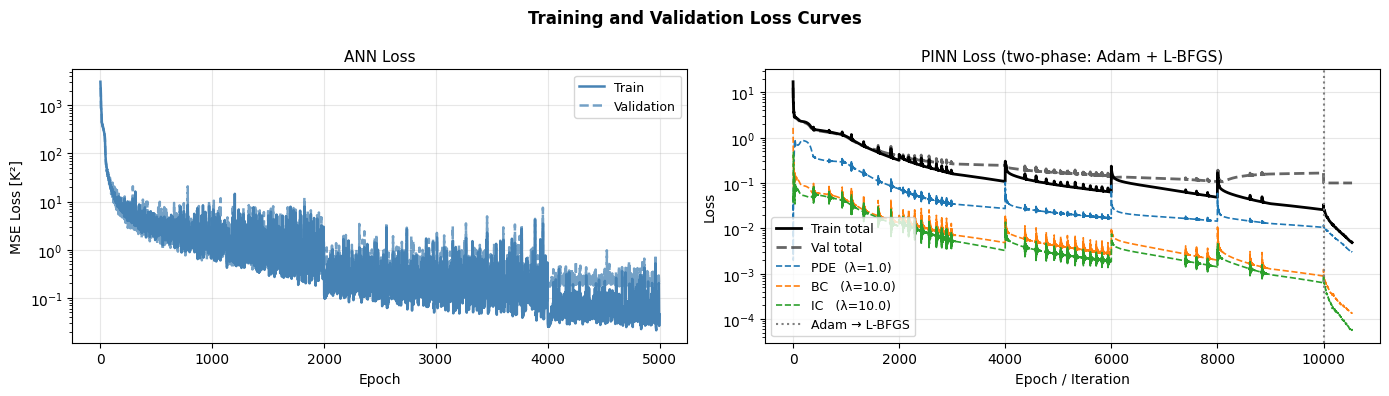

In [8]:
# ── Loss curves — training and validation ─────────────────────────────────────
plot_loss_curves(loss_ann, loss_pinn,
                 lambda_pde=LAMBDA_PDE, lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC)


### Interpreting the Loss Curves

**ANN:** A gap between train and validation loss indicates overfitting —
the model has memorised the training data and does not generalise.
If the validation loss increases while training loss decreases, stop training earlier.

**PINN:** Train and validation losses use different (non-overlapping) collocation
points but the same physics. A large gap here is unusual — if it occurs, the
model may be fitting the specific random collocation points rather than the
underlying physics. Re-sampling collocation points or increasing `N_col` may help.


---
## Section 6: Evaluation and Benchmarking

In [9]:
# ── Evaluate all training meats ───────────────────────────────────────────────
print("=" * 65)
eval_results = {}
for meat in MEAT_PROPERTIES:
    print()
    r_ann  = evaluate_model(ann,  meat, MEAT_PROPERTIES[meat],
                             fdm_data[meat], device=device)
    r_pinn = evaluate_model(pinn, meat, MEAT_PROPERTIES[meat],
                             fdm_data[meat], device=device)
    eval_results[meat] = {'ann': r_ann, 'pinn': r_pinn}
print("=" * 65)



ANN    | beef     | t = 894 s
  MAE  vs FDM  : 0.2988 K   RMSE: 0.6237 K
  MAE  vs Exact: 0.3975 K   RMSE: 0.6646 K
PINN   | beef     | t = 894 s
  MAE  vs FDM  : 3.3948 K   RMSE: 3.9204 K
  MAE  vs Exact: 3.2669 K   RMSE: 3.7734 K

ANN    | chicken  | t = 894 s
  MAE  vs FDM  : 0.3190 K   RMSE: 0.7208 K
  MAE  vs Exact: 0.4421 K   RMSE: 0.7623 K
PINN   | chicken  | t = 894 s
  MAE  vs FDM  : 2.4446 K   RMSE: 3.1308 K
  MAE  vs Exact: 2.5508 K   RMSE: 3.2432 K

ANN    | pork     | t = 894 s
  MAE  vs FDM  : 0.2773 K   RMSE: 0.5791 K
  MAE  vs Exact: 0.3688 K   RMSE: 0.6158 K
PINN   | pork     | t = 894 s
  MAE  vs FDM  : 2.2471 K   RMSE: 2.7484 K
  MAE  vs Exact: 2.1098 K   RMSE: 2.5935 K


In [10]:
print_metrics_table(eval_results)

Meat       Model    MAE vs FDM   RMSE vs FDM  MAE vs Exact
----------------------------------------------------------
beef       ANN          0.2988 K       0.6237 K       0.3975 K
beef       PINN         3.3948 K       3.9204 K       3.2669 K

chicken    ANN          0.3190 K       0.7208 K       0.4421 K
chicken    PINN         2.4446 K       3.1308 K       2.5508 K

pork       ANN          0.2773 K       0.5791 K       0.3688 K
pork       PINN         2.2471 K       2.7484 K       2.1098 K



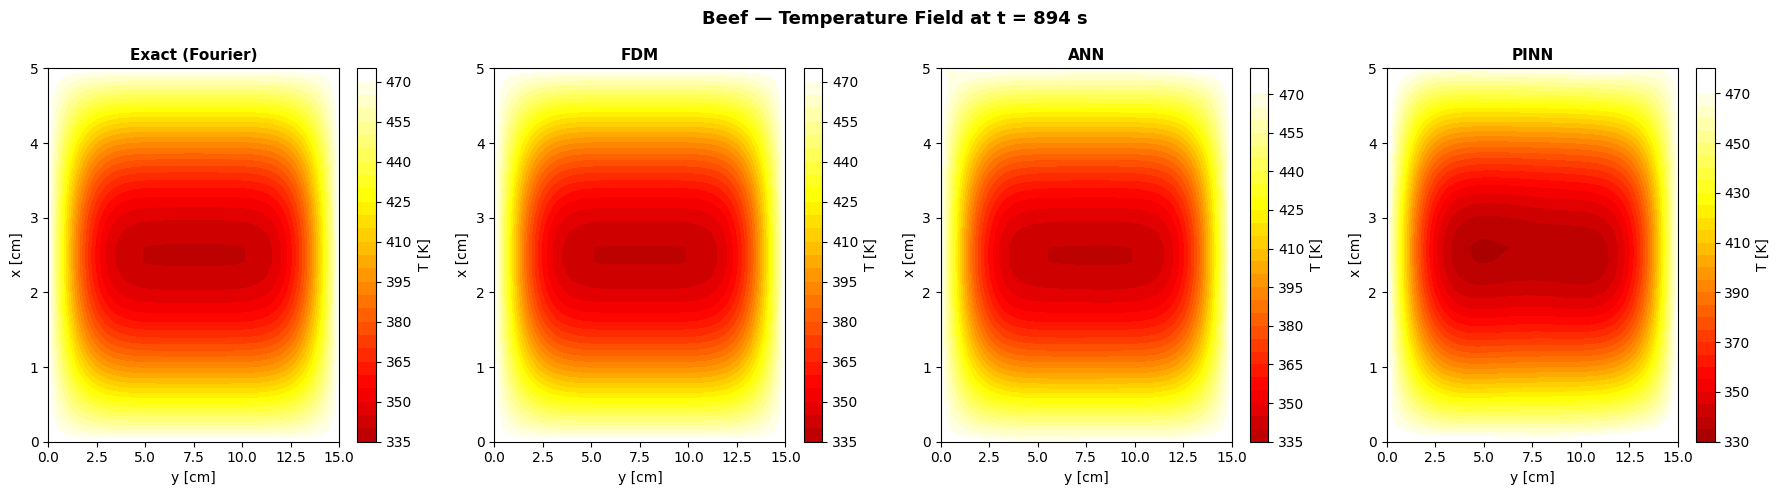

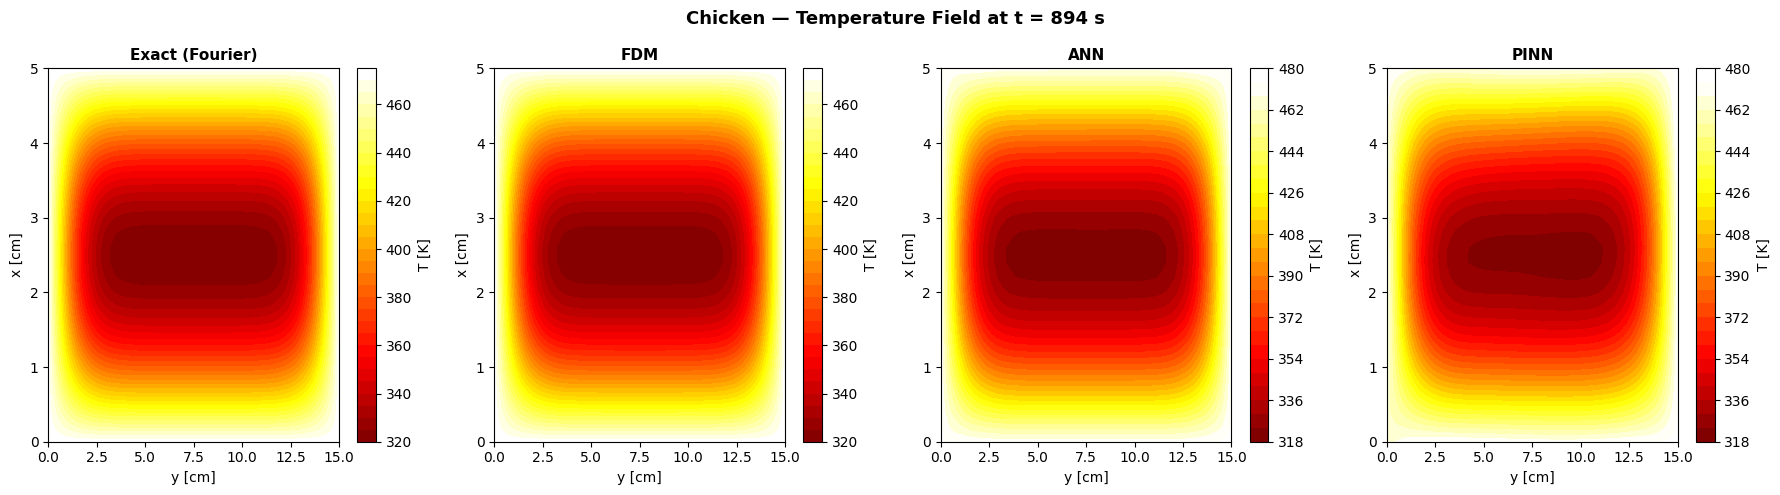

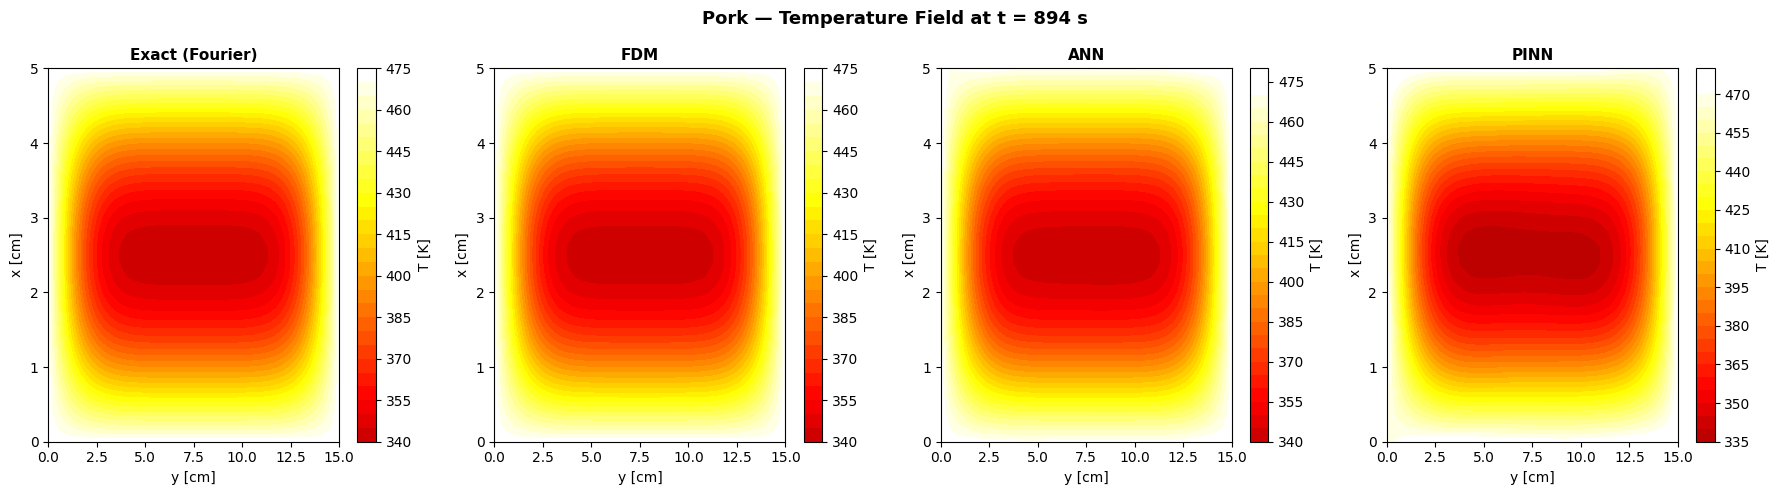

In [12]:
for meat in MEAT_PROPERTIES:
    plot_field_comparison(meat, eval_results[meat]['ann'],
                           eval_results[meat]['pinn'],
                           fdm_data[meat]['x'], fdm_data[meat]['y'])


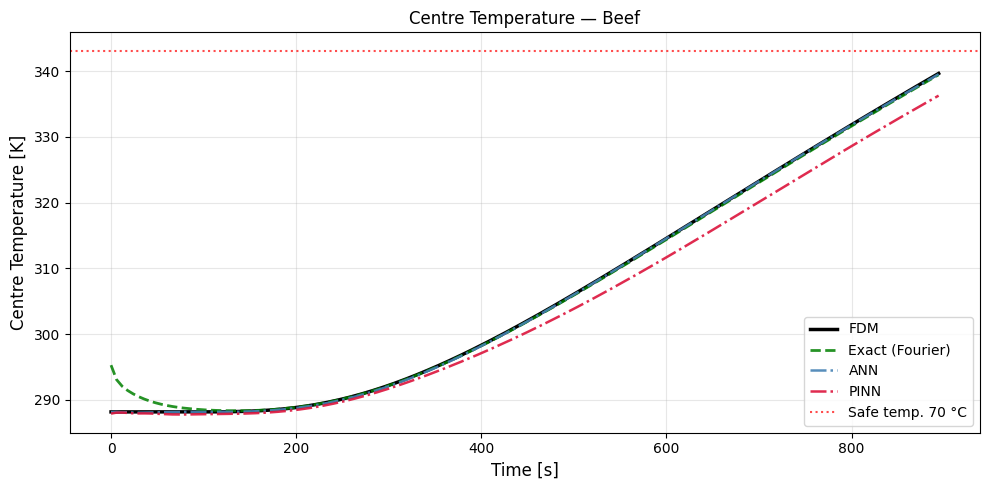

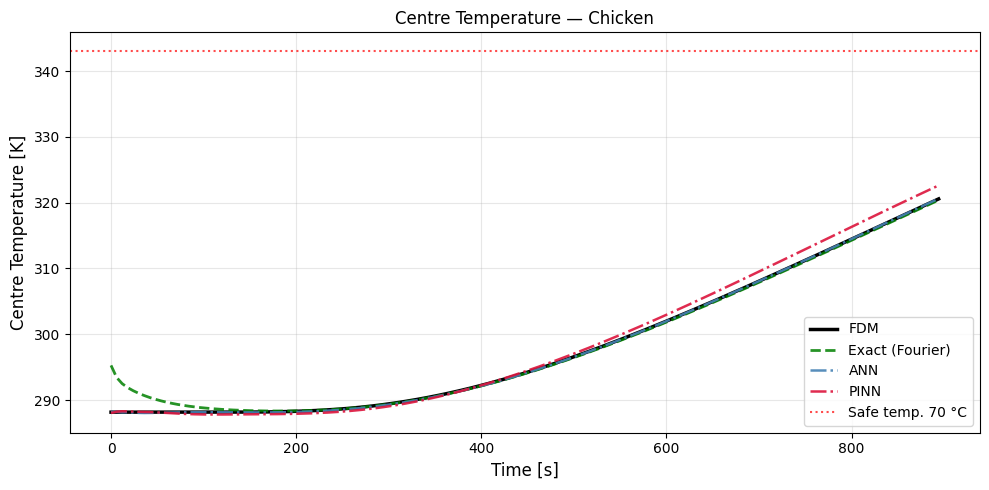

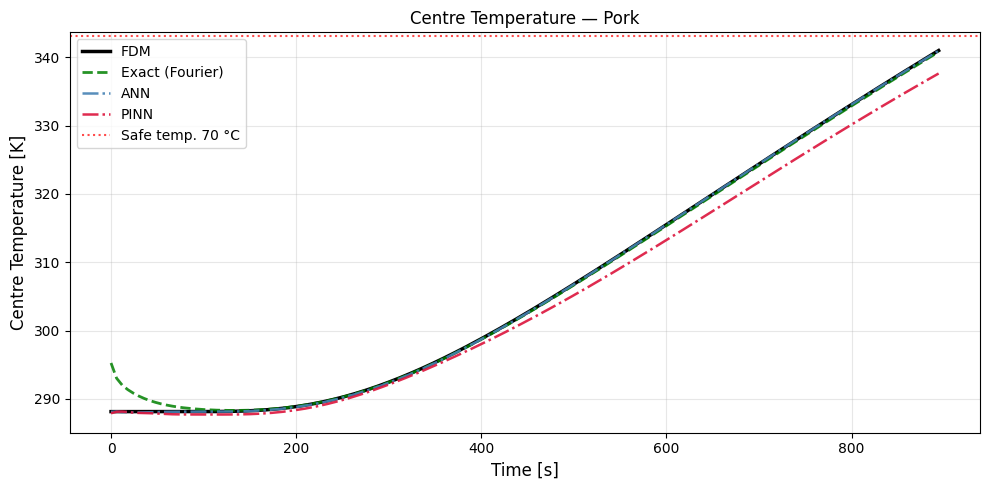

In [11]:
for meat in MEAT_PROPERTIES:
    plot_centre_temperature(meat, MEAT_PROPERTIES[meat], fdm_data[meat],
                             models_dict={'ANN': ann, 'PINN': pinn}, device=device)


### Critical Note

The ANN outperforms the PINN on the training meats — this is expected. The ANN has seen this exact data; the PINN has not. Before drawing conclusions, proceed to Section 8 and evaluate both models on lamb, a material neither model has encountered. The results will reframe what you see here.

---
## Section 7: Hyperparameter Tuning  *(Student Task)*

### Background
Hyperparameters are set before training and control the network structure
and optimisation process. They are not learned — you must choose them
deliberately and justify your choices.

### How to run an experiment
Each experiment below has a clearly labelled code block. To run it:
1. Scroll to the **CHANGE THIS** line in the block
2. Update the single value indicated
3. Run the cell — training, evaluation and logging happen automatically
4. Read the printed output and note what changed

You do not need to rerun the baseline models. Each experiment creates a
fresh model independently.

### Experiments to run

| # | What you vary | Values to test |
|---|--------------|---------------|
| 1 | Network depth (`N_HIDDEN`) | 2, 5, 8 |
| 2 | Learning rate (`LR`) | 1e-2, 1e-3, 1e-4 |
| 3 | Loss weights (`LAMBDA_BC`, `LAMBDA_IC`) | 1, 10, 50 |

Run each experiment for all values listed. Use `print_experiment_log()`
at the end to produce your results table for the report.

### Reflection Questions

**Q1 — Network depth:**
How does changing `N_HIDDEN` affect the training loss curve and final accuracy?
At what depth does performance plateau or degrade? What does this reveal about
the representational capacity needed for this problem?

**Q2 — Learning rate:**
What happens when the learning rate is too high? Too low? Examine both the
loss curve shape and the final MAE. Why does Adam handle this differently
from a fixed learning rate method?

**Q3 — Loss weights:**
When `LAMBDA_BC = LAMBDA_IC = 1`, what happens to PINN accuracy?
When set to 50, what changes? Explain in terms of the competition between
the PDE residual and the boundary/initial condition terms during training.


In [14]:
import torch.nn as nn

def run_experiment(model_type='PINN',
                   n_hidden=5, n_neurons=40,
                   lr=1e-3, epochs_adam=5000, epochs_lbfgs=200,
                   lambda_pde=1.0, lambda_bc=10.0, lambda_ic=10.0,
                   label=None):
    """
    Train a fresh model with the given hyperparameters and evaluate on beef.

    Returns
    -------
    model   : trained model
    history : loss history dict
    metrics : error metrics dict
    """
    if label is None:
        label = f"{model_type} | layers={n_hidden} | lr={lr:.0e} | λbc={lambda_bc}"
    set_seed(GLOBAL_SEED)  # Reset all seeds before each experiment
    print(f"\nExperiment: {label}")
    print("-" * 60)

    if model_type == 'PINN':
        model = PINN(n_hidden=n_hidden, n_neurons=n_neurons,
                      lambda_pde=lambda_pde, lambda_bc=lambda_bc,
                      lambda_ic=lambda_ic).to(device)
        history = train_pinn(model, col, col_val,
                              epochs_adam=epochs_adam, lr=lr,
                              epochs_lbfgs=epochs_lbfgs,
                              resample_every=2000,
                              print_every=max(1, epochs_adam//5),
                              device=device)
    else:
        model = ANN(n_hidden=n_hidden, n_neurons=n_neurons).to(device)
        history = train_ann(model, train_loader, val_loader,
                             epochs=epochs_adam, lr=lr,
                             print_every=max(1, epochs_adam//5),
                             device=device)

    result = evaluate_model(model, 'beef', MEAT_PROPERTIES['beef'],
                             fdm_data['beef'], device=device)
    return model, history, result['metrics']


experiment_log = []

def log_experiment(label, model, metrics, notes=''):
    """Record an experiment result."""
    experiment_log.append({'label': label, 'model': model, **metrics, 'notes': notes})
    print(f"Logged: {label}")

def print_experiment_log():
    if not experiment_log:
        print("No experiments recorded yet.")
        return
    header = f"{'#':<4} {'Label':<45} {'MAE vs FDM':>11} {'RMSE vs FDM':>12}  Notes"
    print(header); print("-" * len(header))
    for i, r in enumerate(experiment_log, 1):
        print(f"{i:<4} {r['label']:<45} {r.get('mae_fdm', float('nan')):>11.4f}"
              f" {r.get('rmse_fdm', float('nan')):>11.4f}   {r.get('notes', '')}")
    print(f"\nTo use experiment N as your best model, write:")
    print(f"  best_pinn = experiment_log[N-1]['model']")

print("Experiment runner defined. Proceed to the experiments below.")


Experiment runner defined. Proceed to the experiments below.


### Experiment 1 — Network Depth
Run this cell three times, changing `N_HIDDEN_EXP` to **2**, then **5**, then **8**.

In [15]:
# ── CHANGE THIS: add or remove values from the list ──────────────────────────
depth_values = [2, 5, 8]
# ─────────────────────────────────────────────────────────────────────────────

for n in depth_values:
    label = f"PINN | depth={n} layers"
    model_exp1, hist_exp1, met_exp1 = run_experiment(
        model_type='PINN', n_hidden=n, n_neurons=N_NEURONS,
        lr=LR, epochs_adam=EPOCHS_ADAM, epochs_lbfgs=EPOCHS_LBFGS,
        lambda_pde=LAMBDA_PDE, lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
        label=label)
    log_experiment(label, model_exp1, met_exp1, notes=f'N_HIDDEN={n}')


Experiment: PINN | depth=2 layers
------------------------------------------------------------
Training PINN | Adam=10000 epochs + L-BFGS=500 iters | params=1,961
  λ_pde=1.0 | λ_bc=10.0 | λ_ic=10.0
  Collocation resampling every 2000 epochs
-----------------------------------------------------------------
  [Adam] epoch   2000 | train=8.6212e-01 val=8.5676e-01 | pde=2.1869e-01 bc=3.4888e-02 ic=2.9455e-02 | 12.2 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   4000 | train=6.5226e-01 val=6.3245e-01 | pde=1.3837e-01 bc=2.4726e-02 ic=2.6663e-02 | 25.1 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   6000 | train=5.8040e-01 val=5.5584e-01 | pde=1.1600e-01 bc=2.2444e-02 ic=2.3995e-02 | 36.8 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   8000 | train=4.8897e-01 val=4.9456e-01 | pde

### Experiment 2 — Learning Rate
Run this cell three times, changing `LR_EXP` to **1e-2**, then **1e-3**, then **1e-4**.

In [16]:
# ── CHANGE THIS ───────────────────────────────────────────────────────────────
lr_values = [1e-2, 1e-3, 1e-4]
# ─────────────────────────────────────────────────────────────────────────────

for lr_exp in lr_values:
    label = f"PINN | lr={lr_exp:.0e}"
    model_exp2, hist_exp2, met_exp2 = run_experiment(
        model_type='PINN', n_hidden=N_HIDDEN, n_neurons=N_NEURONS,
        lr=lr_exp, epochs_adam=EPOCHS_ADAM, epochs_lbfgs=EPOCHS_LBFGS,
        lambda_pde=LAMBDA_PDE, lambda_bc=LAMBDA_BC, lambda_ic=LAMBDA_IC,
        label=label)
    log_experiment(label, model_exp2, met_exp2, notes=f'LR={lr_exp:.0e}')


Experiment: PINN | lr=1e-02
------------------------------------------------------------
Training PINN | Adam=10000 epochs + L-BFGS=500 iters | params=6,881
  λ_pde=1.0 | λ_bc=10.0 | λ_ic=10.0
  Collocation resampling every 2000 epochs
-----------------------------------------------------------------
  [Adam] epoch   2000 | train=6.4878e-02 val=1.4217e-01 | pde=2.0555e-02 bc=3.6052e-03 ic=8.2716e-04 | 20.3 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   4000 | train=2.0805e-02 val=1.0116e-01 | pde=6.4823e-03 bc=1.3227e-03 ic=1.0954e-04 | 40.0 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   6000 | train=2.9342e-01 val=4.1156e-01 | pde=1.1995e-01 bc=1.3999e-02 ic=3.3487e-03 | 59.8 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   8000 | train=1.9887e-02 val=8.2717e-02 | pde=8.355

### Experiment 3 — Loss Weights
Run this cell three times, changing `LAMBDA_EXP` to **1**, then **10**, then **50**.

In [17]:
# ── CHANGE THIS ───────────────────────────────────────────────────────────────
lambda_values = [1, 10, 50]
# ─────────────────────────────────────────────────────────────────────────────

for lam in lambda_values:
    label = f"PINN | λ_bc=λ_ic={lam}"
    model_exp3, hist_exp3, met_exp3 = run_experiment(
        model_type='PINN', n_hidden=N_HIDDEN, n_neurons=N_NEURONS,
        lr=LR, epochs_adam=EPOCHS_ADAM, epochs_lbfgs=EPOCHS_LBFGS,
        lambda_pde=LAMBDA_PDE, lambda_bc=lam, lambda_ic=lam,
        label=label)
    log_experiment(label, model_exp3, met_exp3, notes=f'lambda_bc=lambda_ic={lam}')



Experiment: PINN | λ_bc=λ_ic=1
------------------------------------------------------------
Training PINN | Adam=10000 epochs + L-BFGS=500 iters | params=6,881
  λ_pde=1.0 | λ_bc=1 | λ_ic=1
  Collocation resampling every 2000 epochs
-----------------------------------------------------------------
  [Adam] epoch   2000 | train=3.7780e-02 val=4.3666e-02 | pde=6.2632e-03 bc=1.6351e-02 ic=1.5166e-02 | 20.4 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   4000 | train=2.1660e-02 val=2.5653e-02 | pde=3.8290e-03 bc=1.0150e-02 ic=7.6810e-03 | 40.8 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   6000 | train=1.0033e-02 val=2.6791e-02 | pde=2.4854e-03 bc=4.5219e-03 ic=3.0255e-03 | 61.0 s
PINN collocation points:
  Train — PDE: 10,000 | BC: 800 | IC: 800
  Val   — PDE: 1 | BC: 1 | IC: 1
  [Adam] epoch   8000 | train=1.0684e-02 val=1.3804e-02 | pde=2.2085e-

### Results Summary

In [18]:
# ── Experiment results ────────────────────────────────────────────────────────
# Note: the variable names model_exp1, model_exp2, model_exp3 always hold the
# last model trained in each loop. To retrieve any specific model for Section 8,
# use the experiment log by number — e.g. experiment_log[2]['model'] retrieves
# experiment #3. Run this cell first to see which number corresponds to which
# configuration, then assign your best PINN in Section 8 accordingly.
# ─────────────────────────────────────────────────────────────────────────────
print_experiment_log()

#    Label                                          MAE vs FDM  RMSE vs FDM  Notes
----------------------------------------------------------------------------------
1    PINN | depth=2 layers                              5.8070      7.4526   N_HIDDEN=2
2    PINN | depth=5 layers                              3.4702      3.9236   N_HIDDEN=5
3    PINN | depth=8 layers                              2.3263      2.6562   N_HIDDEN=8
4    PINN | lr=1e-02                                    1.2522      1.6378   LR=1e-02
5    PINN | lr=1e-03                                    3.5262      4.0008   LR=1e-03
6    PINN | lr=1e-04                                    4.1291      5.1105   LR=1e-04
7    PINN | λ_bc=λ_ic=1                                 2.1531      2.6186   lambda_bc=lambda_ic=1
8    PINN | λ_bc=λ_ic=10                                3.5262      4.0008   lambda_bc=lambda_ic=10
9    PINN | λ_bc=λ_ic=50                                2.8365      3.4657   lambda_bc=lambda_ic=50

To use exper

---
## Section 8: Test Meat — Generalisation Evaluation  *(Student Task)*

Your models were trained on **beef, chicken, and pork**.  
Now evaluate your best models on **lamb** — never seen during training.

### Your Task
1. Replace `best_ann` and `best_pinn` with your best models from Section 7
2. Evaluate on lamb and compare errors to the training meat results
3. In your report, explain which model generalises better and why


In [19]:
# ── Load lamb FDM reference ───────────────────────────────────────────────────
print("Loading test meat (lamb) reference...")
raw_lamb   = load_meat_data(DATA_DIR, 'lamb')
props_lamb = TEST_MEAT['lamb']
nx_int, ny_int = NX - 2, NY - 2
n_spatial = nx_int * ny_int

x_grid = np.linspace(0, XMAX, NX)
y_grid = np.linspace(0, YMAX, NY)
t_grid = np.arange(NT) * DT

u_lamb = np.full((NX, NY, NT), T_BOUNDARY)
for it in range(NT):
    u_lamb[1:-1, 1:-1, it] = raw_lamb['T'][it*n_spatial:(it+1)*n_spatial].reshape(nx_int, ny_int)

fdm_lamb = {'u': u_lamb, 'x': x_grid, 'y': y_grid, 't': t_grid, **props_lamb}
alpha_lamb = props_lamb['k'] / (props_lamb['rho'] * props_lamb['cp'])
print(f"Lamb: alpha={alpha_lamb:.3e} m²/s | T_centre(final)={u_lamb[NX//2,NY//2,-1]:.2f} K")


Loading test meat (lamb) reference...
Lamb: alpha=1.450e-07 m²/s | T_centre(final)=333.20 K


In [20]:
# ── Substitute your best models from Section 7 ───────────────────────────────
# best_ann  — always use the baseline ANN from Section 5 (do not change).
#             The ANN is not tuned in Section 7; it serves as a fixed
#             data-driven reference to compare against your best PINN.
#
# best_pinn — replace 'pinn' with your best PINN from Section 7.
#             Use the experiment log to identify the best configuration:
#               1. Run print_experiment_log() above to see all results
#               2. Identify the experiment number with the lowest MAE vs FDM
#               3. Assign it here — e.g. for experiment #3:
#                  best_pinn = experiment_log[2]['model']
#
#             Note: experiment_log indices are zero-based, so experiment #N
#             is accessed as experiment_log[N-1]['model']
# ─────────────────────────────────────────────────────────────────────────────

best_ann  = ann                            # Fixed — Section 5 baseline (do not change). We are only tuning the PINN in Section 7, so we keep the ANN as a constant reference.

# CHANGE THIS: assign your best PINN from the experiment log (see instructions above)__________________
best_pinn = experiment_log[3]['model']     # Replace 0 with your best experiment index
# _____________________________________________________________________________________________________
print(f"Evaluating on lamb with:")
print(f"  best_ann  : {best_ann.__class__.__name__}  "
      f"({best_ann.n_hidden} layers × {best_ann.n_neurons} neurons)")
print(f"  best_pinn : {best_pinn.__class__.__name__} "
      f"({best_pinn.n_hidden} layers × {best_pinn.n_neurons} neurons)")

print("ANN on lamb:")
r_ann_lamb  = evaluate_model(best_ann,  'lamb', props_lamb, fdm_lamb, device=device)
print()
print("PINN on lamb:")
r_pinn_lamb = evaluate_model(best_pinn, 'lamb', props_lamb, fdm_lamb, device=device)


Evaluating on lamb with:
  best_ann  : ANN  (5 layers × 40 neurons)
  best_pinn : PINN (5 layers × 40 neurons)
ANN on lamb:
ANN    | lamb     | t = 894 s
  MAE  vs FDM  : 13.1082 K   RMSE: 18.4442 K
  MAE  vs Exact: 13.2043 K   RMSE: 18.5695 K

PINN on lamb:
PINN   | lamb     | t = 894 s
  MAE  vs FDM  : 0.7905 K   RMSE: 0.9680 K
  MAE  vs Exact: 0.7793 K   RMSE: 0.9416 K


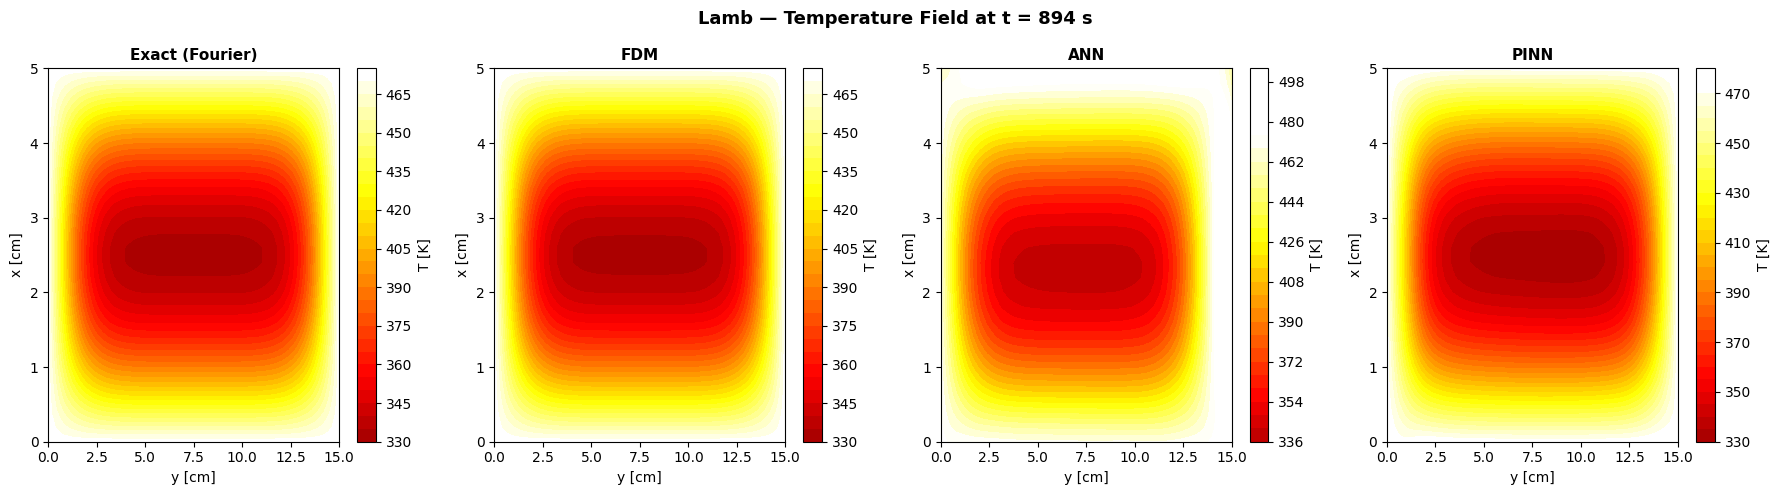

In [21]:
plot_field_comparison('lamb', r_ann_lamb, r_pinn_lamb, x_grid, y_grid)

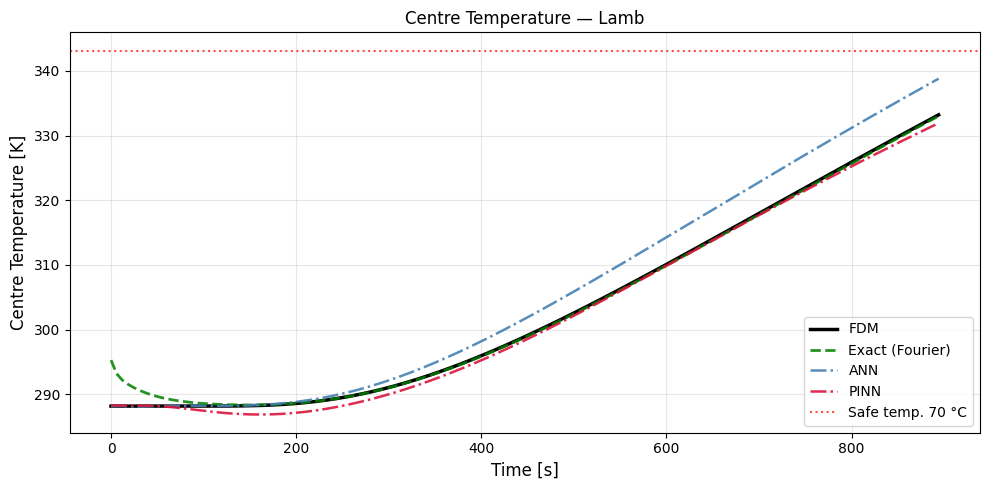

In [22]:
plot_centre_temperature('lamb', props_lamb, fdm_lamb,
                         models_dict={'ANN': best_ann, 'PINN': best_pinn},
                         device=device)


---
### Reflection — Revisiting Section 6

In Section 6 you observed that the ANN outperformed the PINN on all three
training meats (beef, chicken, pork). This is expected — the ANN was trained
directly on data from those materials.

Now that you have evaluated both models on lamb, revisit that observation:

- Which model performed better on the unseen material?
- What does this tell you about the difference between learning from data
  versus learning from physics?
- The ANN has never seen lamb data, and neither has the PINN. Why do their
  generalisation errors differ so significantly?
- In an engineering context, which model would you trust more when applying
  it to a new material you have no data for? Why?

This contrast — strong performance on training conditions versus strong
generalisation to new conditions — is one of the central arguments for
physics-informed approaches in scientific machine learning. A model that
knows the governing equations does not need to have seen every possible
material to make physically consistent predictions.

Incorporate this reflection into your report discussion in Section 9.

---
## Section 9: Report Guidance

### 1. Model Understanding
- Describe the network architecture and the role of each hyperparameter
- Derive the chain rule used to compute physical derivatives from normalised-coordinate outputs
- Explain the composite PINN loss — what does each term enforce?
- Why is `tanh` required for PINN autograd?

### 2. Hyperparameter Study
- Present all experiments using `print_experiment_log()`
- For each hyperparameter: describe the trend and provide a physical/mathematical explanation
- Include train vs validation loss curves for each experiment — discuss any overfitting

### 3. Benchmarking — Training Meats
- Compare ANN, PINN, FDM, and Exact (MAE, RMSE) for all three training meats
- Plot temperature fields and centre temperature histories
- Discuss where each method performs best and worst

### 4. Generalisation — Test Meat (Lamb)
- Compare ANN and PINN on the unseen test material
- Which generalises better, and why?

### 5. Critical Method Comparison

| Criterion | FDM | ANN | PINN |
|-----------|-----|-----|------|
| Requires simulation data | ✓ | ✓ | ✗ |
| Enforces physics | ✓ | ✗ | ✓ |
| Generalises across materials | Re-run required | Partially | ✓ |
| Inference cost | High | Low | Low |
| Interpretability | High | Low | Medium |

---
*Department of Mechanical & Aeronautical Engineering | University of Pretoria*
